In [4]:
# 셀 2: 임포트
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ 라이브러리 임포트 완료")

✅ 라이브러리 임포트 완료


In [5]:
# 셀 3: 피처 컬럼 정의
# 데이터 들어오면 여기 컬럼명만 맞춰주면 됨

FEATURE_COLUMNS = [
    # KoBERT 감성 점수 (A팀원이 만들어서 넘겨줌)
    'sentiment_overall',     # 전체 감성 점수
    'sentiment_whitening',   # 백탁 없음 점수
    'sentiment_texture',     # 발림성 점수
    'sentiment_moisture',    # 보습 점수
    'sentiment_irritation',  # 자극 점수 (낮을수록 좋음)

    # Google Trends
    'trend_score_us',        # 미국 검색량
    'trend_growth_3m',       # 최근 3개월 성장률

    # 규제 DB
    'prohibited_count',      # 금지 성분 수
    'restricted_count',      # 제한 성분 수
    'sunscreen_banned_count',# 선케어 미승인 성분 수

    # 올리브영 기본 정보
    'category',              # 카테고리
    'price',                 # 가격
    'review_count',          # 리뷰 수
    'rating',                # 평점
]

TARGET = 'market_fit_score'  # 예측할 값 (0~100)

print("✅ 피처 정의 완료")
print(f"총 피처 수: {len(FEATURE_COLUMNS)}개")

✅ 피처 정의 완료
총 피처 수: 14개


In [6]:
# 셀 4: 더미 데이터 (실제 데이터 준비되면 이 셀만 교체)
np.random.seed(42)
N = 500

dummy_df = pd.DataFrame({
    'sentiment_overall':      np.random.uniform(0.3, 1.0, N),
    'sentiment_whitening':    np.random.uniform(0.0, 1.0, N),
    'sentiment_texture':      np.random.uniform(0.0, 1.0, N),
    'sentiment_moisture':     np.random.uniform(0.0, 1.0, N),
    'sentiment_irritation':   np.random.uniform(0.0, 0.5, N),
    'trend_score_us':         np.random.uniform(0, 100, N),
    'trend_growth_3m':        np.random.uniform(-0.5, 2.0, N),
    'prohibited_count':       np.random.randint(0, 3, N),
    'restricted_count':       np.random.randint(0, 5, N),
    'sunscreen_banned_count': np.random.randint(0, 2, N),
    'category':               np.random.choice([0, 1, 2, 3], N),  # 인코딩됨
    'price':                  np.random.randint(5000, 80000, N),
    'review_count':           np.random.randint(10, 10000, N),
    'rating':                 np.random.uniform(3.0, 5.0, N),
})

# 타겟: 규칙 기반으로 초기 스코어 생성 (Phase 1)
dummy_df[TARGET] = (
    dummy_df['sentiment_overall']   * 30 +
    dummy_df['sentiment_whitening'] * 10 +
    dummy_df['trend_score_us']      * 0.25 +
    dummy_df['trend_growth_3m']     * 8 +
    (1 - dummy_df['prohibited_count'] * 0.3) * 15 +
    (dummy_df['rating'] - 3)        * 5
).clip(0, 100)

print("✅ 더미 데이터 생성 완료")
print(f"Shape: {dummy_df.shape}")
dummy_df.head()

✅ 더미 데이터 생성 완료
Shape: (500, 15)


,sentiment_overall,sentiment_whitening,sentiment_texture,sentiment_moisture,sentiment_irritation,trend_score_us,trend_growth_3m,prohibited_count,restricted_count,sunscreen_banned_count,category,price,review_count,rating,market_fit_score
0,0.562178,0.698162,0.185133,0.519082,0.130853,82.751892,1.181757,2,1,1,3,76537,6489,4.964965,69.813818
1,0.965500,0.536096,0.541901,0.479182,0.123489,76.452779,1.491703,0,4,0,0,9567,6974,4.823637,89.490973
2,0.812396,0.309528,0.872946,0.025642,0.453127,57.352895,0.126170,2,1,0,0,79807,8085,3.878261,53.206037
3,0.719061,0.813795,0.732225,0.341248,0.124773,95.604714,1.062185,2,3,0,0,18329,4462,3.079896,68.507919
4,0.409213,0.684731,0.806561,0.380196,0.135975,20.047452,0.929365,0,2,0,2,76792,8457,3.724587,50.193421


In [8]:
# 셀 5: 학습/테스트 분리 및 모델 학습
X = dummy_df[FEATURE_COLUMNS]
y = dummy_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# LightGBM 파라미터
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'n_estimators': 200,
    'verbose': -1,
}

model = lgb.LGBMRegressor(**params)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(20), lgb.log_evaluation(50)]
)

# 성능 확인
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"\n✅ 모델 학습 완료")
print(f"RMSE: {rmse:.2f}")

Training until validation scores don't improve for 20 rounds
[50]	valid_0's rmse: 4.19511
[100]	valid_0's rmse: 2.78738
[150]	valid_0's rmse: 2.48292
[200]	valid_0's rmse: 2.37742
Did not meet early stopping. Best iteration is:
[200]	valid_0's rmse: 2.37742

✅ 모델 학습 완료
RMSE: 2.38


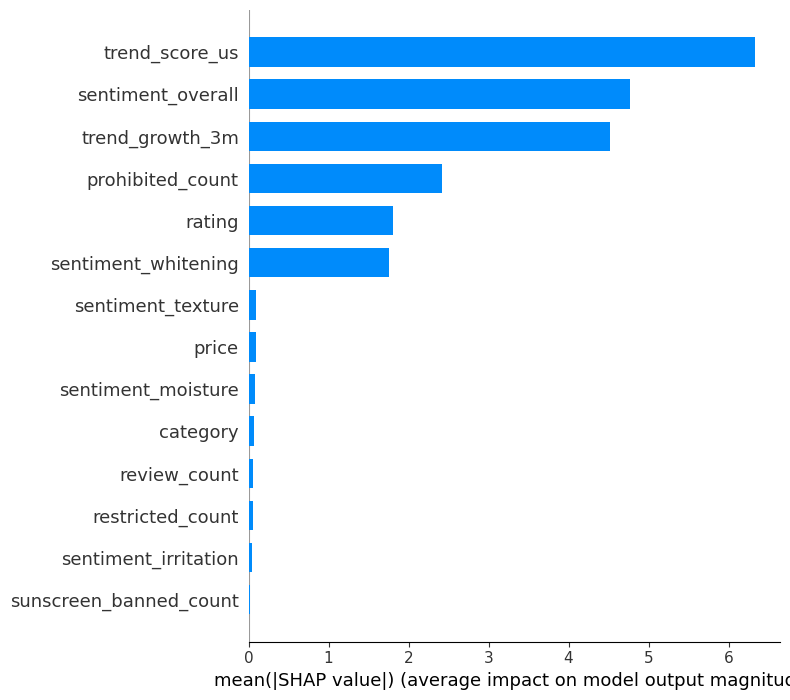

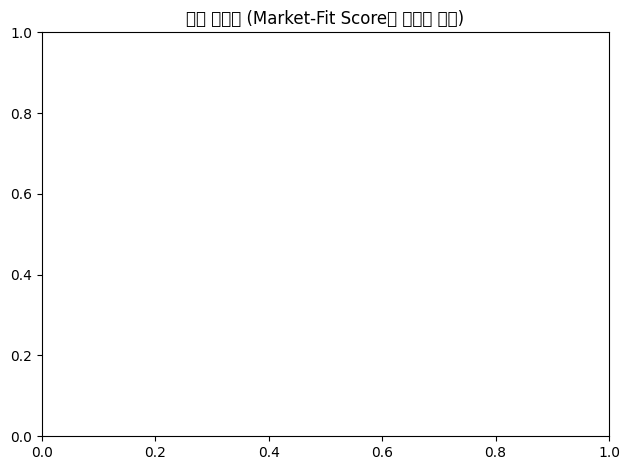

In [9]:
# 셀 6: SHAP - "왜 이 점수인가?" 시각화
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 전체 피처 중요도
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.title("피처 중요도 (Market-Fit Score에 미치는 영향)")
plt.tight_layout()
plt.show()

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


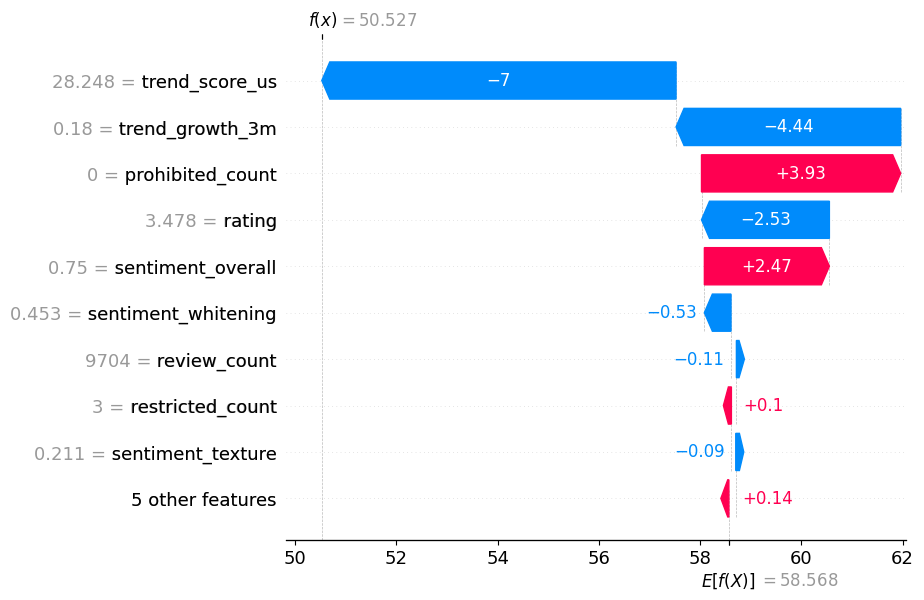

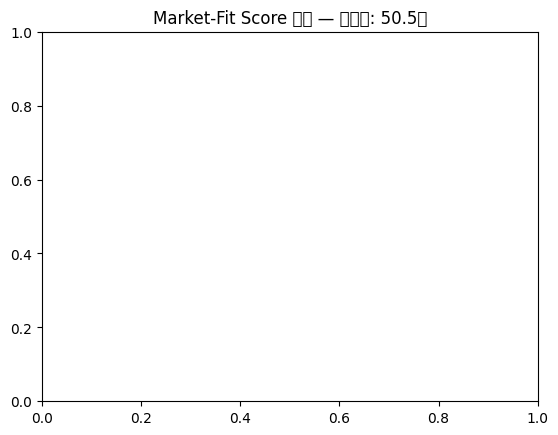

In [10]:
# 셀 7: 특정 제품 1개 설명 (발표 킥 장면)
sample_idx = 0
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_idx],
        feature_names=FEATURE_COLUMNS
    )
)
plt.title(f"Market-Fit Score 근거 — 예측값: {y_pred[sample_idx]:.1f}점")
plt.show()

In [11]:
# 셀 8: 모델 저장
import joblib
import os

os.makedirs('../00_data', exist_ok=True)
joblib.dump(model, '../00_data/model_score.pkl')
print("✅ 모델 저장 완료: ../00_data/model_score.pkl")

✅ 모델 저장 완료: ../00_data/model_score.pkl
